### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time as tm

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

In [12]:
#definiendo parametros
N_max = 50
d = 10
delta_d = 0
l = 10
a = (N_max-d-(2*delta_d))/2
b = a + delta_d + d
c = (N_max-l)/2

P = 50
V = np.zeros((N_max,N_max),float)

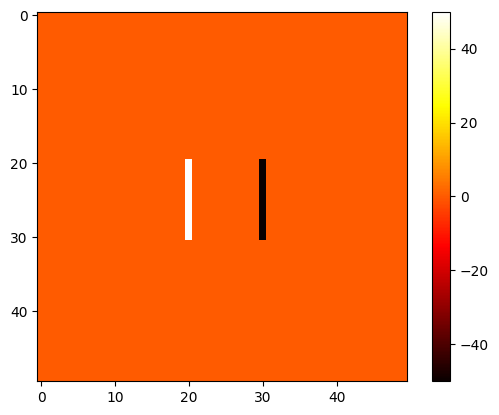

In [13]:
#Condiciones iniciales
V = np.zeros((N_max,N_max),float)

for i in range(N_max):
  for j in range(N_max):
    if j >= a and j <= a+delta_d and i >= c and i <= c+l:
      V[i,j] = P
    elif j >= b and j <= b+delta_d and i >= c and i <= c+l:
      V[i,j] = -P

plt.imshow(V, cmap = "hot", vmin = -P, vmax = P)
plt.colorbar()
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_50359/851144600.py:34: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Capacitor con potencial $\phi$(x,y)")


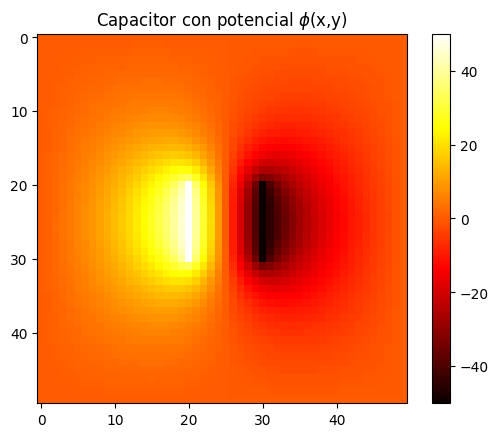

In [11]:
N_max, Niter = 50, 200

V0 = np.zeros((N_max,N_max),float)

def Capacitor(V,Niter):
  Nmax = V.shape[0]
  #parametros
  d = 10
  delta_d = 0
  l = 10
  P = 50
  a = (N_max-d-(2*delta_d))/2
  b = a + delta_d + d
  c = (N_max-l)/2

  #Resolucion de la ecuacion
  for iter in range(Niter+1):

    for i in range(1,Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

        #Mantener las placas con igual potencial
        if j >= a and j <= a+delta_d and i >= c and i <= c+l:
          V[i,j] = P
        elif j >= b and j <= b+delta_d and i >= c and i <= c+l:
          V[i,j] = -P

  return V

V_sol = Capacitor(V0,Niter)

plt.imshow(V_sol, cmap = "hot", vmin = -P, vmax = P)
plt.colorbar()
plt.title("Capacitor con potencial $\phi$(x,y)")
plt.show()

* Compute numerically (use finite difference method) the electric field.

La ecuacion del campo electrico en 2D se define como:

$$\vec{E}(x,y) = \nabla \phi(x,y) $$

Aplicando el metodo de diferencias finitas, haciendo las derivadas a ambos lados para cada variable

Derivada derecha
$$\phi(x + \Delta x,y) = \phi + \frac{\partial \phi}{\partial x}\Delta x + \frac{1}{2} \frac{\partial ^2 \phi}{\partial x^2}(\Delta x)^2 + ...$$

Derivada izquierda

$$\phi(x - \Delta x,y) = \phi - \frac{\partial \phi}{\partial x}\Delta x + \frac{1}{2} \frac{\partial ^2 \phi}{\partial x^2}(\Delta x)^2 + ...$$

Restando estas dos cantidades obtenemos y despejando $\frac{\partial \phi}{\partial x}$

$$\frac{\partial \phi}{\partial x} ≈ \frac{\phi(x+\Delta x,y)-\phi(x-\Delta x,y)}{2\Delta x}$$

Y analogamente para y

$$\frac{\partial \phi}{\partial y} ≈ \frac{\phi(x, y+\Delta y)-\phi(x,y -\Delta y)}{2\Delta y}$$

Entonces obtenemos

$$\nabla \phi = \frac{\partial \phi}{\partial x}\hat{i} + \frac{\partial \phi}{\partial y}\hat{j} = \frac{\phi(x+\Delta x,y)-\phi(x-\Delta x,y)}{2\Delta x}\hat{i} + \frac{\phi(x, y+\Delta y)-\phi(x,y -\Delta y)}{2\Delta y}\hat{j} $$

Finalmente obtendremos

$$\vec{E} = -\frac{\phi(x+\Delta x,y)-\phi(x-\Delta x,y)}{2\Delta x}\hat{i} - \frac{\phi(x, y+\Delta y)-\phi(x,y -\Delta y)}{2\Delta y}\hat{j} $$
Con $\vec{E} = (E_x,E_y)$ nos queda

$$E_x = -\frac{\phi(x+\Delta x,y)-\phi(x-\Delta x,y)}{2\Delta x}$$
$$E_y = -\frac{\phi(x,y+\Delta y)-\phi(x,y-\Delta y)}{2\Delta y}$$

Suponiendo ahora que $\Delta x = \Delta y = \Delta$ y asignando la notacion $ x_i = x_0 + i\Delta $ y $y_j = y_0 + j\Delta$ para ${i,j} = 0,...,N $

$$E_{x_{i,j}} = -\frac{1}{2}[\frac{\phi_{i+1,j}-\phi_{i-1,j}}{\Delta}]$$
$$E_{y_{i,j}} = -\frac{1}{2}[\frac{\phi_{i,j+1}-\phi_{i,j-1}}{\Delta}]$$

Estas son nuestras expresiones para el calculo de las componentes del campo $\vec{E}$ con el metodo de diferencias finitas. Ahora solo diseñemos el codigo que las calcula.

In [14]:
#Funcion para el calculo del Campo electrico
def Campo_E(E,Niter,d):

  Nmax = E.shape[0]

  Ex = np.zeros((Nmax,Nmax),float)
  Ey = np.zeros((Nmax,Nmax),float)

  for iter in range(Niter):
    for i in range(1,Nmax-1):
      for j in range(1,Nmax-1):
        Ex[i,j] = 1/2*((E[i+1,j]-E[i-1,j])/d)
        Ey[i,j] = -1/2*((E[i,j+1]-E[i,j-1])/d)


  return Ex, Ey

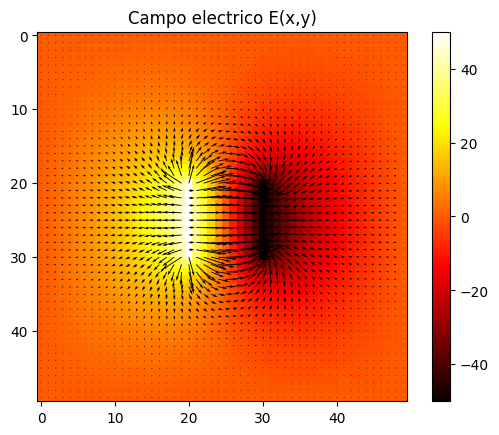

In [16]:
x = np.arange(N_max)
y = x

X , Y = np.meshgrid(x,y)

d = 0.1

E = V_sol.copy()

Ex , Ey = Campo_E(E,200,d)

plt.quiver(X,Y,Ey,Ex)
plt.imshow(V_sol, cmap = "hot", vmin = -P, vmax = P)
plt.colorbar()
plt.title("Campo electrico E(x,y)")
plt.show()

NOTA: muy buen trabajo. np.quiver se logra ver en detalle. la barra no tiene unidades. Nota 5